In [1]:
import os
import h5py
import numpy as np
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import yaml
import optax

In [2]:
import sys
sys.path.append('/Users/mariana/Documents/projects/Huawei/survan')
sys.path.append('/home/mvargas/code/Huawei/survan')

from lambda_cox import LambdaSA
from utils import concordance_index, unroll, get_single_task_dataset

In [3]:
def score(beta, xs):
    return -jnp.dot(xs, beta)

In [6]:
data_path = '/Users/mariana/Documents/projects/Huawei/cloudproject/data/Delays/new_data_b03-09_online/train'

In [7]:
seqs, ts, cs = get_single_task_dataset(4, data_path, horizon=350)

In [8]:
config_path = '../config.yaml'
config = yaml.load(open(config_path, 'r'), Loader=yaml.FullLoader)

agent = LambdaSA(config, 42)

In [9]:
# TODO: ts as in baseline
agent.config.weight_decay

1e-05

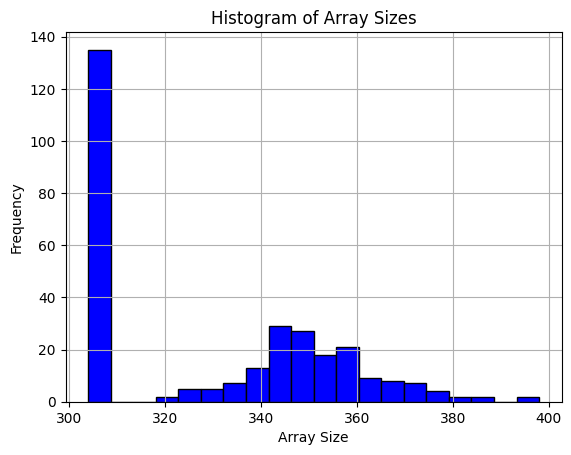

In [10]:
sizes = agent.data['ts']

# Create a histogram of the sizes
plt.hist(sizes, bins=20, color='blue', edgecolor='black')
plt.xlabel('Array Size')
plt.ylabel('Frequency')
plt.title('Histogram of Array Sizes')
plt.grid(True)

# Show the histogram
plt.show()


In [11]:
agent = LambdaSA(config, 42)
agent.lambda_ = 0.0
X_train, X_test, ts_train, ts_test, cs_train, cs_test = agent._get_train_test()
losses = agent.train(X_train, ts_train, cs_train)

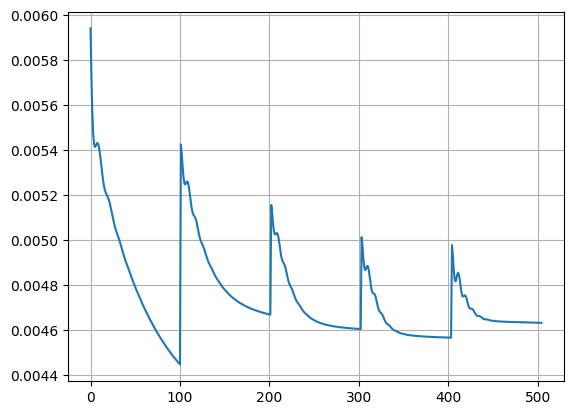

In [12]:
plt.plot(np.hstack(losses))
plt.grid()

In [13]:
agent.data['seqs'].shape

(296, 350, 39)

In [14]:
%%time

num_exps = 5
sizes = [50, 100, 237]

res2_is = np.zeros((num_exps, len(sizes)))
res2_lm = np.zeros((num_exps, len(sizes)))
res2_td = np.zeros((num_exps, len(sizes)))

res3_is = np.zeros((num_exps, len(sizes)))
res3_lm = np.zeros((num_exps, len(sizes)))
res3_td = np.zeros((num_exps, len(sizes)))

for fold in range(num_exps):
    seqs_t, seqs_v, ts_t, ts_v, cs_t, cs_v = agent._get_train_test()
    for i, size in enumerate(sizes):
        print(".", end="")
        seqs_, ts_, cs_ = unroll(seqs_t[:size], ts_t[:size], cs_t[:size])
        
        # Initial state.
        model = LambdaSA(config, 42)
        model.train(seqs_t[:size], ts_t[:size], cs_t[:size])
        res2_is[fold, i] = model.integrated_brier_score(seqs_v[:, 0], ts_v, cs_v)
        beta = model.state.params['cox_linear_model']['beta']
        scores = score(beta, seqs_v[:, 0])
        res3_is[fold, i] = concordance_index(scores, ts_v, cs_v)
        
        # Landmarking.
        model = LambdaSA(config, 42)
        model.lambda_ = 1.0
        model.train(seqs_, ts_, cs_)
        res2_lm[fold, i] = model.integrated_brier_score(seqs_v[:, 0], ts_v, cs_v)
        beta = model.state.params['cox_linear_model']['beta']
        scores = score(beta, seqs_v[:, 0])
        res3_lm[fold, i] = concordance_index(scores, ts_v, cs_v)
        
        # Temporal difference.
        model = LambdaSA(config, 42)
        model.lambda_ = 0.0
        model.train(seqs_, ts_, cs_)
        res2_td[fold, i] = model.integrated_brier_score(seqs_v[:, 0], ts_v, cs_v)
        beta = model.state.params['cox_linear_model']['beta']
        scores = score(beta, seqs_v[:, 0])
        res3_td[fold, i] = concordance_index(scores, ts_v, cs_v)
        
    print()

...
...
...
...
...
CPU times: user 1h 21min 56s, sys: 39min 3s, total: 2h 59s
Wall time: 1h 9min 14s


Text(0.5, 0, 'Number of patients')

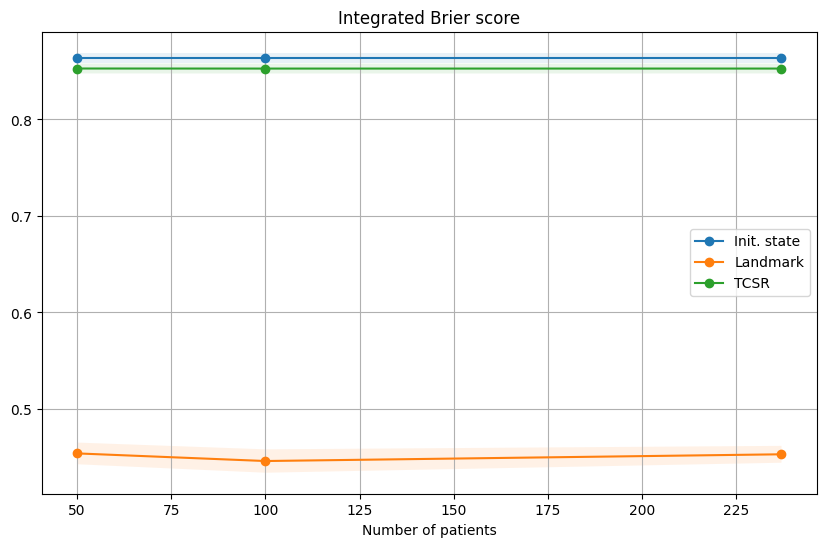

In [15]:
fig, ax = plt.subplots(figsize=(10, 6))

for res, label in ((res2_is, "Init. state"), (res2_lm, "Landmark"), (res2_td, "TCSR")):
    mean = res.mean(axis=0)
    std = res.std(axis=0) / np.sqrt(num_exps)
    ax.plot(sizes, mean, marker="o", label=label)
    ax.fill_between(sizes, mean - std, mean + std, alpha=0.1)

ax.legend()
ax.grid()
ax.set_title("Integrated Brier score")
ax.set_xlabel("Number of patients")

Text(0.5, 0, 'Number of patients')

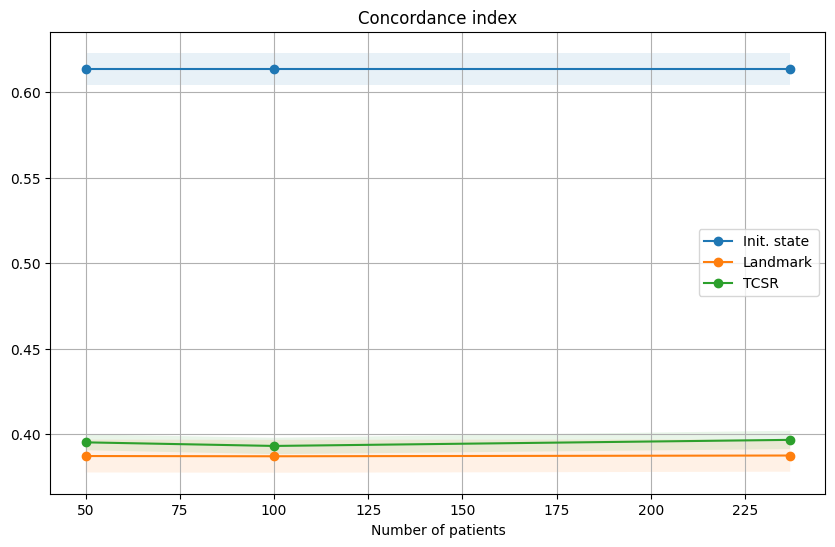

In [16]:
fig, ax = plt.subplots(figsize=(10, 6))

for res, label in ((res3_is, "Init. state"), (res3_lm, "Landmark"), (res3_td, "TCSR")):
    mean = res.mean(axis=0)
    std = res.std(axis=0) / np.sqrt(num_exps)
    ax.plot(sizes, mean, marker="o", label=label)
    ax.fill_between(sizes, mean - std, mean + std, alpha=0.1)

ax.legend()
ax.grid()
ax.set_title("Concordance index")
ax.set_xlabel("Number of patients")

In [17]:
agent.state.params

{'cox_linear_model': {'alpha': Array([-1.69571018e+00, -3.74801844e-01,  8.22483063e-01,  1.98673606e+00,
          3.19481826e+00,  4.58570957e+00,  4.39947844e+00,  4.21147060e+00,
          4.03062534e+00,  3.87448549e+00,  3.74903679e+00,  3.64917827e+00,
          3.56377745e+00,  3.47766471e+00,  3.37059069e+00,  3.21472049e+00,
          2.97384119e+00,  2.61160302e+00,  2.12293196e+00,  1.58215141e+00,
          1.11615801e+00,  7.89222121e-01,  5.79750896e-01,  4.44321305e-01,
          3.52083713e-01,  2.85834312e-01,  2.36327037e-01,  1.98326096e-01,
          1.68610111e-01,  1.45040303e-01,  1.26115859e-01,  1.10747561e-01,
          9.81279090e-02,  8.76520425e-02,  7.88623542e-02,  7.14109689e-02,
          6.50314093e-02,  5.95185347e-02,  5.47133200e-02,  5.04914857e-02,
          4.67553288e-02,  4.34272625e-02,  4.04450856e-02,  3.77586856e-02,
          3.53272185e-02,  3.31170782e-02,  3.11003644e-02,  2.92538516e-02,
          2.75578648e-02,  2.59957016e-02,  2.4

In [49]:
X_train[0]

Array([[0.        , 0.62823665, 0.65400183, ..., 0.772517  , 0.8502585 ,
        0.8145863 ],
       [0.00251256, 0.5498282 , 0.552334  , ..., 0.64036196, 1.        ,
        1.        ],
       [0.00502513, 0.76637155, 0.7705579 , ..., 0.6067518 , 0.8339199 ,
        0.8254351 ],
       ...,
       [0.8718593 , 0.8334748 , 0.84492046, ..., 0.6329556 , 0.6912598 ,
        0.6676272 ],
       [0.8743719 , 0.866956  , 0.8582654 , ..., 0.6778133 , 0.744893  ,
        0.70386815],
       [0.8768844 , 0.876474  , 0.8631214 , ..., 0.7058735 , 0.7632537 ,
        0.735148  ]], dtype=float32)